# IMPORT LIBRARY

In [99]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision import datasets

from torchvision.models import (
    swin_t,
    Swin_T_Weights
)

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from tqdm import tqdm

# Device setting

In [100]:
if torch.backends.mps.is_available():

    DEVICE = torch.device("mps")

else:

    DEVICE = torch.device("cpu")

print("Using Device:", DEVICE)

Using Device: mps


# Dataset directory

In [101]:

TRAIN_DIR = "./cifar10/train"

TEST_DIR = "./cifar10/test"


# Necessary Settings for model

In [102]:
IMG_SIZE = 224

BATCH_SIZE = 16

EPOCHS_stage_1 = 20


LR = 1e-4

WEIGHT_DECAY = 1e-4

PATIENCE = 7

LABEL_SMOOTHING = 0.1

NUM_WORKERS = 0

# Preprocessing and Augmentation

In [103]:
train_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])


# DATASETS LOAD


In [ ]:


train_dataset = datasets.ImageFolder(

    TRAIN_DIR,

    transform=train_transform
)

test_dataset = datasets.ImageFolder(

    TEST_DIR,

    transform=test_transform
)

NUM_CLASSES = len(train_dataset.classes)

print("\nClasses:")
print(train_dataset.classes)

print(f"\nTrain Images: {len(train_dataset)}")

print(f"Test Images : {len(test_dataset)}")


Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Train Images: 50000
Test Images : 10000


In [ ]:

# DATALOADERS


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=False
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=False
)

# MODEL Swin-T

In [ ]:


model = swin_t(

    weights=Swin_T_Weights.DEFAULT
)

for param in model.parameters():
    param.requires_grad = False

in_features = model.head.in_features

model.head = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.GELU(),
    nn.Dropout(0.5),

    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.GELU(),
    nn.Dropout(0.3),

    nn.Linear(256, NUM_CLASSES)
)

model = model.to(DEVICE)

print("\nSwin Transformer Ready")


Swin Transformer Ready


# LOSS FUNCTION

In [ ]:
criterion = nn.CrossEntropyLoss(

    label_smoothing=LABEL_SMOOTHING
)

# OPTIMIZER

In [ ]:
optimizer = optim.AdamW(

    model.head.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

In [ ]:
# SCHEDULER

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=EPOCHS_stage_1
)

# TRAINING with CIFAR10 dataset

In [ ]:
# =========================================================
# TRAINING
# =========================================================

best_val_acc = 0.0

counter = 0

print("\n==============================")
print("TRAINING STARTED")
print("==============================")

for epoch in range(EPOCHS_stage_1):



    model.train()

    train_loss = 0.0

    train_correct = 0

    train_total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            preds == labels
        ).sum().item()

    train_acc = 100 * train_correct / train_total

    train_loss /= len(train_loader)


    # VALIDATION USING TEST SET


    model.eval()

    val_loss = 0.0

    val_correct = 0

    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(DEVICE)

            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (
                preds == labels
            ).sum().item()

    val_acc = 100 * val_correct / val_total

    val_loss /= len(test_loader)

    scheduler.step()

    print(

        f"\nEpoch [{epoch+1}/{EPOCHS_stage_1}] "

        f"Train Loss: {train_loss:.4f} | "

        f"Train Acc: {train_acc:.2f}% | "

        f"Val Loss: {val_loss:.4f} | "

        f"Val Acc: {val_acc:.2f}%"
    )

    # SAVE BEST MODEL

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(

            model.state_dict(),

            "swin_model.pth"
        )

        counter = 0

        print(
            f"✅ Best model saved "
            f"(Val Acc: {best_val_acc:.2f}%)"
        )

    else:

        counter += 1

        if counter >= PATIENCE:

            print("\n⏹️ Early stopping")

            break


TRAINING STARTED


100%|██████████| 3125/3125 [07:33<00:00,  6.90it/s]



Epoch [1/20] Train Loss: 0.9765 | Train Acc: 82.11% | Val Loss: 0.7293 | Val Acc: 91.61%
✅ Best model saved (Val Acc: 91.61%)


100%|██████████| 3125/3125 [07:36<00:00,  6.84it/s]



Epoch [2/20] Train Loss: 0.8450 | Train Acc: 86.87% | Val Loss: 0.7043 | Val Acc: 92.17%
✅ Best model saved (Val Acc: 92.17%)


...


Epoch [9/20] Train Loss: 0.9599 | Train Acc: 81.49% | Val Loss: 0.7776 | Val Acc: 88.85%


100%|██████████| 3125/3125 [07:27<00:00,  6.98it/s]



Epoch [10/20] Train Loss: 0.9076 | Train Acc: 83.85% | Val Loss: 0.7474 | Val Acc: 90.08%


100%|██████████| 3125/3125 [07:28<00:00,  6.97it/s]



Epoch [11/20] Train Loss: 0.8696 | Train Acc: 85.47% | Val Loss: 0.7281 | Val Acc: 90.81%

⏹️ Early stopping


# FINAL MODEL EVALUATION

In [ ]:


model.load_state_dict(

    torch.load(

        "swin_model.pth",

        map_location=DEVICE
    )
)

model.eval()



all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


# METRICS


accuracy = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_preds,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)



print("\n==============================")
print("FINAL RESULTS")
print("==============================")

print(f"Accuracy : {accuracy*100:.2f}%")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")


# CLASSIFICATION REPORT

print("\nClassification Report:\n")

print(

    classification_report(

        all_labels,

        all_preds,

        target_names=train_dataset.classes
    )
)


FINAL RESULTS
Accuracy : 92.64%
Precision: 0.9262
Recall   : 0.9264
F1 Score : 0.9262

Classification Report:

              precision    recall  f1-score   support

    airplane       0.93      0.94      0.93      1000
  automobile       0.95      0.95      0.95      1000
        bird       0.93      0.90      0.91      1000
         cat       0.88      0.85      0.87      1000
        deer       0.91      0.92      0.92      1000
         dog       0.90      0.88      0.89      1000
        frog       0.95      0.95      0.95      1000
       horse       0.94      0.94      0.94      1000
        ship       0.95      0.96      0.96      1000
       truck       0.93      0.96      0.94      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



# CONFUSION MATRIX

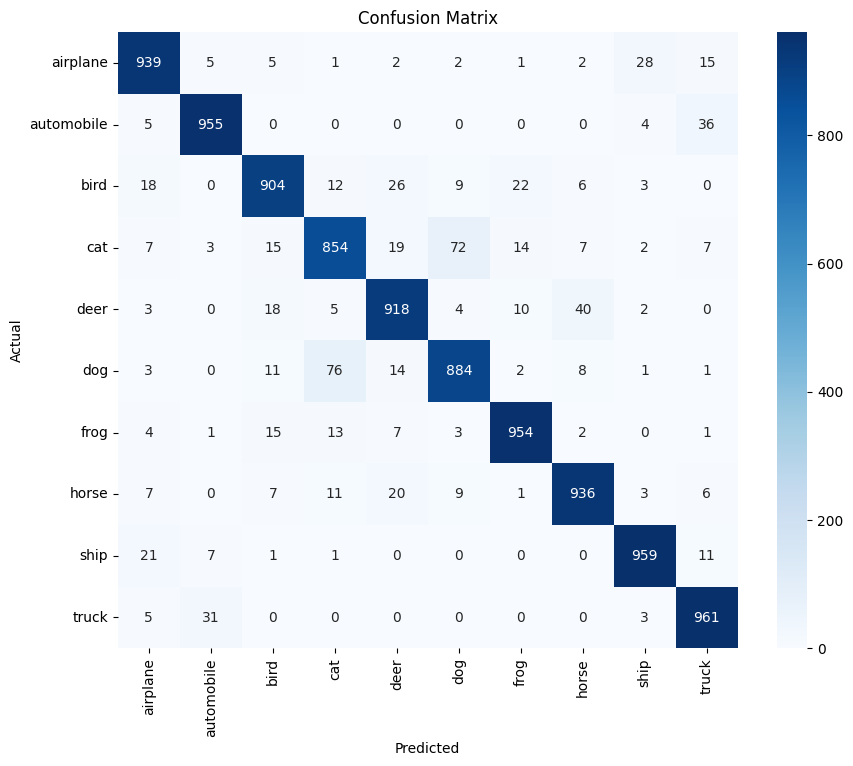

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=train_dataset.classes,

    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# ROC CURVE with AUC SCORE

y_true shape : (10000, 10)
y_score shape: (10000, 10)


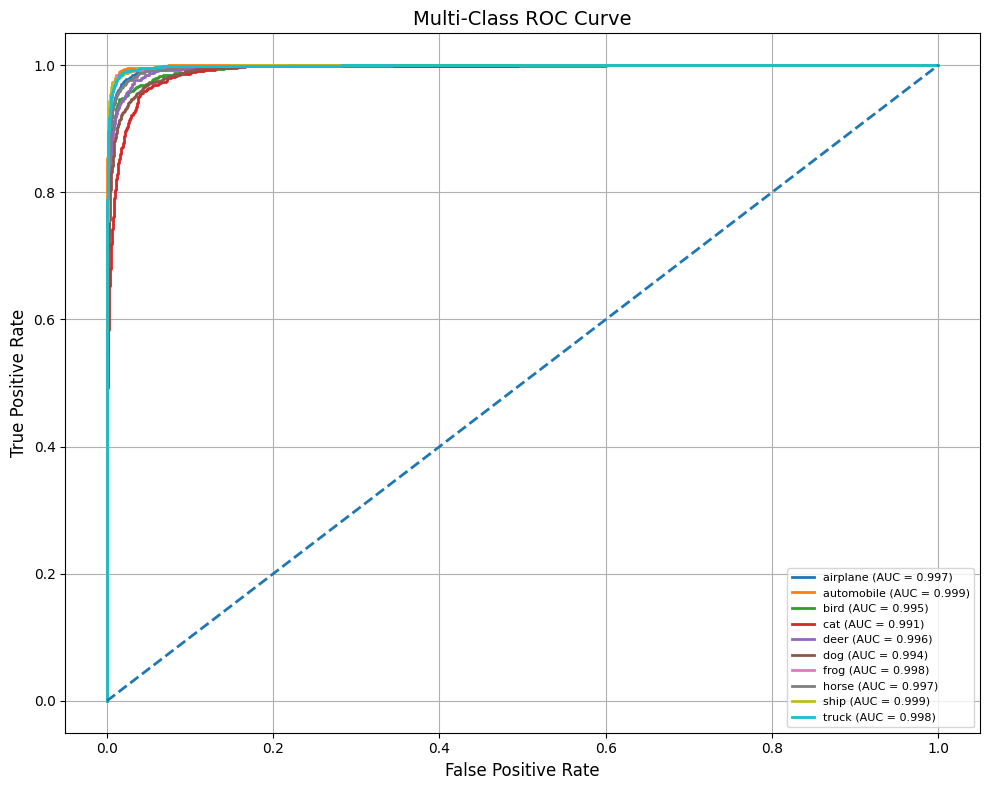

AUC SCORES
Macro AUC    : 0.9965
Weighted AUC : 0.9965


In [113]:



import numpy as np


from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score
)


# GET PROBABILITIES FROM TEST SET


all_probs = []
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        _, preds = torch.max(
            probs,
            dim=1
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


# CONVERT TO NUMPY


y_true = label_binarize(
    all_labels,
    classes=np.arange(NUM_CLASSES)
)

y_score = np.array(all_probs)

print("y_true shape :", y_true.shape)
print("y_score shape:", y_score.shape)

# Expected:
# y_true shape : (N, NUM_CLASSES)
# y_score shape: (N, NUM_CLASSES)

# ROC CURVE

plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true[:, i],
        y_score[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{train_dataset.classes[i]} "
              f"(AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "Multi-Class ROC Curve",
    fontsize=14
)

plt.legend(
    loc="lower right",
    fontsize=8
)

plt.grid(True)

plt.tight_layout()

plt.show()

# MACRO & WEIGHTED AUC

auc_macro = roc_auc_score(
    y_true,
    y_score,
    multi_class="ovr",
    average="macro"
)

auc_weighted = roc_auc_score(
    y_true,
    y_score,
    multi_class="ovr",
    average="weighted"
)

print("AUC SCORES")

print(
    f"Macro AUC    : {auc_macro:.4f}"
)

print(
    f"Weighted AUC : {auc_weighted:.4f}"
)